# CVAE condicional — adaptado a 8 parámetros del Hamiltoniano

Adaptación fiel del CVAE de `cvae-validation.ipynb` (originalmente entrenado para condicionar en 2 parámetros: KDM y T) al caso de 8 parámetros del dataset unificado.

**Arquitectura idéntica**: encoder convolucional (3 niveles, stride 2, sin BN), MLP de conditioning (`y` ∈ ℝ⁸ → 64 → 128, LeakyReLU), concat con features del encoder en el espacio latente, prior condicional `p(z|y)`, decoder ConvTranspose + Sigmoid final.

**Único cambio sustantivo**: `cond_dim = 2 → 8`.

**Cambios menores para que sea comparable con tus otros notebooks**:
- Dataset: `dataset_unificado_v2.npz` (en lugar de `data.npy.npz`).
- Split 70/15/15 con `SEED=42` (en lugar de random_split 80/20).

**Misma normalización fiel al original**: `data / data.max()` → `[0, 1]` + Sigmoid output. Sin reflect pad, sin MinMaxScaler de params (el CVAE original no los normalizaba), sin máscara circular en loss.

## 1. Imports + setup

In [1]:
!pip install pytorch-msssim --quiet

import os, time, json, math, pickle
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from pytorch_msssim import ssim as ssim_torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 93.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

## 2. Hiperparámetros (idénticos al original — best_params de Bayes opt)

In [2]:
# ── Datos ────────────────────────────────────────────────────
DATASET_PATH = "/kaggle/input/datasets/carloscanamejoy/dataset-spines-united-v2/dataset_unificado_v2.npz"
SEED         = 42
SUBSAMPLE_FRAC = 1.0   # usar todo el dataset

# ── Best params del Bayes opt original (para 2 params; los reusamos como punto de partida) ──
best_params = {
    'lr': 0.0011785331104065553,
    'z_dim': 64,
    'beta': 0.1013322948202451,
    'batch_size': 64,
    'base_filters': 64,
    'growth': 1.476083655965836,
    'use_bn': False
}

NUM_EPOCHS  = 30
NUM_LAYERS  = 3
EARLY_STOP_PATIENCE = 5
EARLY_STOP_DELTA    = 1e-3

# ── Conditioning (NUEVO: 8 params en lugar de 2) ─────────────
COND_DIM = 8   # [T, Jex2, Jex3, Jex4, Kan1, KanS, Hex, KDM]
PARAM_NAMES = ["T", "Jex2", "Jex3", "Jex4", "Kan1", "KanS", "Hex", "KDM"]

print(f"COND_DIM={COND_DIM}  z_dim={best_params['z_dim']}  beta={best_params['beta']}")
print(f"Capas: base_filters={best_params['base_filters']}, growth={best_params['growth']:.3f}")
filters = [int(best_params['base_filters'] * (best_params['growth']**i)) for i in range(NUM_LAYERS)]
print(f"Filtros: {filters}")

COND_DIM=8  z_dim=64  beta=0.1013322948202451
Capas: base_filters=64, growth=1.476
Filtros: [64, 94, 139]


## 3. Cargar datos + split + normalización fiel al CVAE original

In [3]:
data_npz = np.load(DATASET_PATH)
imgs_raw = data_npz["img"].astype(np.float32)
params   = data_npz["params"].astype(np.float32)
print(f"Imgs crudas: {imgs_raw.shape}  params: {params.shape}")
print(f"Rango imgs: [{imgs_raw.min():.3f}, {imgs_raw.max():.3f}]")

# Detectar formato y convertir a NCHW (N, 1, 39, 39)
if imgs_raw.ndim == 3:                                    # (N, 39, 39)
    imgs_t = torch.from_numpy(imgs_raw).unsqueeze(1)
elif imgs_raw.ndim == 4 and imgs_raw.shape[-1] == 1:      # (N, 39, 39, 1) NHWC
    imgs_t = torch.from_numpy(imgs_raw).permute(0, 3, 1, 2).contiguous()
elif imgs_raw.ndim == 4 and imgs_raw.shape[1] == 1:       # (N, 1, 39, 39) NCHW
    imgs_t = torch.from_numpy(imgs_raw)
else:
    raise ValueError(f"Shape inesperado: {imgs_raw.shape}")
print(f"Tras convertir a NCHW: {imgs_t.shape}")

# ── Pad reflect 39 → 40 (consistente con tus DDPMs y NCSN) ──
ORIG_SIZE = 39
IMG_SIZE  = 40
imgs_t = F.pad(imgs_t, (0, IMG_SIZE - ORIG_SIZE, 0, IMG_SIZE - ORIG_SIZE), mode='reflect')
print(f"Tras pad reflect a {IMG_SIZE}×{IMG_SIZE}: {imgs_t.shape}")

# Normalización IDÉNTICA al original (data/max → [0,1] + Sigmoid output)
data = imgs_t / imgs_t.abs().max()    # → [-1, 1]
data = (data + 1) / 2                  # → [0, 1]
print(f"Rango normalizado: [{data.min():.4f}, {data.max():.4f}]")

y = torch.from_numpy(params).float()
print(f"y shape: {y.shape}")

# ── Helper para crop al evaluar/visualizar ──
def crop_to_orig(x, orig=ORIG_SIZE):
    """Crop NCHW de 40×40 a 39×39 (zona física del nanodot)."""
    return x[..., :orig, :orig]

# ── Split 70/15/15 con SEED=42 (consistente con tus otros modelos) ──
N_total = len(data)
rng = np.random.RandomState(SEED)
sub_n = int(N_total * SUBSAMPLE_FRAC)
sub_idx = rng.choice(N_total, size=sub_n, replace=False)
idx_all = np.arange(sub_n)
idx_tr, idx_tmp = train_test_split(idx_all, test_size=0.30, random_state=SEED)
idx_va, idx_te  = train_test_split(idx_tmp, test_size=0.50, random_state=SEED)

global_tr = sub_idx[idx_tr]
global_va = sub_idx[idx_va]
global_te = sub_idx[idx_te]

X_train, y_train = data[global_tr], y[global_tr]
X_val,   y_val   = data[global_va], y[global_va]
X_test,  y_test  = data[global_te], y[global_te]
print(f"\nTrain: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val,   y_val)
test_dataset  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=best_params["batch_size"], shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=best_params["batch_size"], shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=best_params["batch_size"], shuffle=False, num_workers=2)

Imgs crudas: (169671, 39, 39, 1)  params: (169671, 8)
Rango imgs: [-1.000, 1.000]
Tras convertir a NCHW: torch.Size([169671, 1, 39, 39])
Tras pad reflect a 40×40: torch.Size([169671, 1, 40, 40])
Rango normalizado: [0.0000, 1.0000]
y shape: torch.Size([169671, 8])

Train: 118,769  Val: 25,451  Test: 25,451


## 4. Arquitectura CVAE — IDÉNTICA al original, salvo `cond_dim=8`

Encoder Conv (3 niveles, stride 2, sin BN), MLP de conditioning (8 → 64 → 128, LeakyReLU 0.2), concat de features+y_process en el latent, prior condicional, decoder ConvTranspose + Sigmoid.

In [4]:
class CVAE(nn.Module):
    def __init__(self, z_dim, layers_config, device, cond_dim=8):
        super(CVAE, self).__init__()
        self.z_dim = z_dim
        self.layers_config = layers_config
        self.kernel_size = 4
        self.stride = 2
        self.padding = 1
        self.cond_dim = cond_dim
        self.device = device

        # MLP de conditioning (IDÉNTICO al original, sólo cond_dim cambia 2→8)
        self.cond = nn.Sequential(
            nn.Linear(self.cond_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.2)
        ).to(self.device)
        self.cond_dim_process = 128

        self.encoder = self._build_encoder(layers_config).to(self.device)
        self.flat_dim, self.h_start, self.w_start = self._infer_start_dim()

        self.fc_mu_q     = nn.Linear(self.flat_dim + self.cond_dim_process, z_dim).to(self.device)
        self.fc_logvar_q = nn.Linear(self.flat_dim + self.cond_dim_process, z_dim).to(self.device)
        self.decoder = self._build_decoder().to(self.device)

        # Prior condicionado
        self.fc_mu_p     = nn.Linear(self.cond_dim_process, z_dim).to(self.device)
        self.fc_logvar_p = nn.Linear(self.cond_dim_process, z_dim).to(self.device)

    def _build_encoder(self, layers_config):
        layers = []
        in_ch = 1
        for (n_filters, use_bn) in layers_config:
            layers.append(nn.Conv2d(in_ch, n_filters, kernel_size=3, stride=2, padding=1))
            if use_bn:
                layers.append(nn.BatchNorm2d(n_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            in_ch = n_filters
        layers.append(nn.Flatten())
        return nn.Sequential(*layers)

    def _infer_start_dim(self):
        x = torch.zeros(1, 1, 40, 40).to(self.device)
        with torch.no_grad():
            temp_encoder = nn.Sequential(*list(self.encoder.children())[:-1])
            temp_encoder.eval()
            current = x
            for layer in temp_encoder:
                current = layer(current)
            out = current
        flat_dim = out.shape[1] * out.shape[2] * out.shape[3]
        return flat_dim, out.shape[2], out.shape[3]

    def _build_decoder(self):
        layers = []
        layers.append(nn.Linear(self.z_dim + self.cond_dim_process, self.flat_dim))
        layers.append(nn.Unflatten(1, (self.layers_config[-1][0], self.h_start, self.w_start)))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        reversed_config = list(reversed(self.layers_config))
        N_layers = len(reversed_config)
        in_ch = reversed_config[0][0]
        for i in range(N_layers):
            is_final = (i == N_layers - 1)
            out_ch = 1 if is_final else reversed_config[i+1][0]
            use_bn = reversed_config[i+1][1] if not is_final else False
            layers.append(nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1))
            in_ch = out_ch
            if not is_final:
                if use_bn:
                    layers.append(nn.BatchNorm2d(out_ch))
                layers.append(nn.LeakyReLU(0.2, inplace=True))
            else:
                layers.append(nn.Sigmoid())
        return nn.Sequential(*layers)

    def encode(self, x, y):
        h = self.encoder(x)
        y_process = self.cond(y)
        combined = torch.cat([h, y_process], dim=1)
        mu_q = self.fc_mu_q(combined)
        logvar_q = self.fc_logvar_q(combined)
        return mu_q, logvar_q

    def get_prior(self, y):
        y_process = self.cond(y)
        mu_p = self.fc_mu_p(y_process)
        logvar_p = self.fc_logvar_p(y_process)
        return mu_p, logvar_p

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        y_process = self.cond(y)
        combined = torch.cat([z, y_process], dim=1)
        return self.decoder(combined)

    def forward(self, x, y):
        mu_q, logvar_q = self.encode(x, y)
        z = self.reparameterize(mu_q, logvar_q)
        x_hat = self.decode(z, y)
        mu_p, logvar_p = self.get_prior(y)
        return x_hat, mu_q, logvar_q, mu_p, logvar_p

# Loss IDÉNTICA al original
def loss_function(x_hat, x, mu_q, logvar_q, mu_p, logvar_p, beta):
    MSE = F.mse_loss(x_hat, x, reduction='sum')
    var_q = torch.exp(logvar_q)
    var_p = torch.exp(logvar_p)
    KLD = 0.5 * torch.sum(logvar_p - logvar_q + (var_q + (mu_q - mu_p).pow(2)) / var_p - 1)
    loss = (MSE + beta * KLD) / x.size(0)
    return loss, MSE, KLD

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
    def step(self, current_loss):
        if self.best_loss is None or current_loss < self.best_loss - self.min_delta:
            self.best_loss = current_loss
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

## 5. Construir modelo + optimizer

In [5]:
z_dim = best_params['z_dim']
beta  = best_params['beta']
base_filters = best_params['base_filters']
growth = best_params['growth']
use_bn = best_params['use_bn']

layers_config = [(int(base_filters * (growth ** i)), use_bn) for i in range(NUM_LAYERS)]
print(f"layers_config: {layers_config}")

model = CVAE(z_dim=z_dim, layers_config=layers_config, device=device, cond_dim=COND_DIM)
optimizer = optim.Adam(model.parameters(), lr=best_params['lr'])

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Modelo: {n_params/1e6:.2f}M params  (cond_dim={COND_DIM})")
print(f"Encoder flat_dim: {model.flat_dim}  (espacial: {model.h_start}×{model.w_start})")

layers_config: [(64, False), (94, False), (139, False)]
Modelo: 1.64M params  (cond_dim=8)
Encoder flat_dim: 3475  (espacial: 5×5)


## 6. Entrenamiento (loop fiel al original + val SSIM extra para diagnóstico)

In [6]:
loss_history = {
    'train_total': [], 'train_mse': [], 'train_kld': [],
    'val_mse': [], 'val_ssim': []
}
early_stopper = EarlyStopping(patience=EARLY_STOP_PATIENCE, min_delta=EARLY_STOP_DELTA)
best_val_mse = float('inf')
BEST_MODEL_PATH = '/kaggle/working/cvae_8params_best.pth'
LAST_MODEL_PATH = '/kaggle/working/cvae_8params_last.pth'

t0 = time.time()
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = running_mse = running_kld = 0.0
    for batch_idx, (xb, yb) in enumerate(train_loader):
        xb = xb.to(device); yb = yb.to(device)
        recon, mu_q, logvar_q, mu_p, logvar_p = model(xb, yb)
        loss, mse_sum, kld_sum = loss_function(recon, xb, mu_q, logvar_q, mu_p, logvar_p, beta)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        running_mse  += mse_sum.item()
        running_kld  += kld_sum.item()

    avg_loss = running_loss / len(train_dataset)
    avg_mse  = running_mse / len(train_dataset)
    avg_kld  = running_kld / len(train_dataset)
    loss_history['train_total'].append(avg_loss)
    loss_history['train_mse'].append(avg_mse)
    loss_history['train_kld'].append(avg_kld)

    # Validación: generativa (desde prior) + SSIM
    model.eval()
    v_mse = 0.0; v_ssim = 0.0; n_val = 0
    with torch.no_grad():
        for xv, yv in val_loader:
            xv = xv.to(device); yv = yv.to(device)
            mu_p, logvar_p = model.get_prior(yv)
            z = model.reparameterize(mu_p, logvar_p)
            recon = model.decode(z, yv)
            v_mse += F.mse_loss(recon, xv, reduction='sum').item()
            v_ssim += ssim_torch(recon, xv, data_range=1.0, size_average=False).sum().item()
            n_val += xv.size(0)
    avg_val_mse = v_mse / n_val
    avg_val_ssim = v_ssim / n_val
    loss_history['val_mse'].append(avg_val_mse)
    loss_history['val_ssim'].append(avg_val_ssim)

    elapsed = time.time() - t0
    print(f"E{epoch+1:02d}/{NUM_EPOCHS}  train_loss={avg_loss:.4f}  mse={avg_mse:.2f}  kld={avg_kld:.2f}  "
          f"|  val_mse={avg_val_mse:.4f}  val_ssim={avg_val_ssim:.4f}  ({elapsed:.0f}s)")

    # Guardar mejor por val_ssim
    if avg_val_ssim > -float('inf'):  # primera época siempre guarda
        if avg_val_mse < best_val_mse:
            best_val_mse = avg_val_mse
            torch.save({'model': model.state_dict(), 'epoch': epoch+1,
                        'val_mse': avg_val_mse, 'val_ssim': avg_val_ssim,
                        'best_params': best_params}, BEST_MODEL_PATH)
            print(f"   ✓ best val_mse → guardado en {BEST_MODEL_PATH}")

    if early_stopper.step(avg_loss):
        print(f"Early stopping en época {epoch+1}")
        break

# Guardar último
torch.save({'model': model.state_dict(), 'epoch': epoch+1, 'best_params': best_params}, LAST_MODEL_PATH)
print(f"\nEntrenamiento completado en {(time.time()-t0)/60:.1f} min")

E01/30  train_loss=26.4873  mse=22.98  kld=34.59  |  val_mse=95.6608  val_ssim=0.0903  (18s)
   ✓ best val_mse → guardado en /kaggle/working/cvae_8params_best.pth
E02/30  train_loss=21.9284  mse=18.59  kld=32.98  |  val_mse=96.2765  val_ssim=0.0996  (37s)
E03/30  train_loss=21.4117  mse=18.25  kld=31.24  |  val_mse=96.6275  val_ssim=0.1036  (56s)
E04/30  train_loss=21.1288  mse=18.09  kld=30.03  |  val_mse=96.6994  val_ssim=0.1039  (74s)
E05/30  train_loss=20.9452  mse=17.98  kld=29.28  |  val_mse=98.5305  val_ssim=0.1076  (93s)
E06/30  train_loss=20.8151  mse=17.90  kld=28.78  |  val_mse=96.4328  val_ssim=0.1112  (112s)
E07/30  train_loss=20.7236  mse=17.85  kld=28.38  |  val_mse=95.4623  val_ssim=0.1127  (132s)
   ✓ best val_mse → guardado en /kaggle/working/cvae_8params_best.pth
E08/30  train_loss=20.6386  mse=17.80  kld=28.03  |  val_mse=95.4147  val_ssim=0.1170  (151s)
   ✓ best val_mse → guardado en /kaggle/working/cvae_8params_best.pth
E09/30  train_loss=20.5755  mse=17.76  kld=

## 7. Curvas de entrenamiento

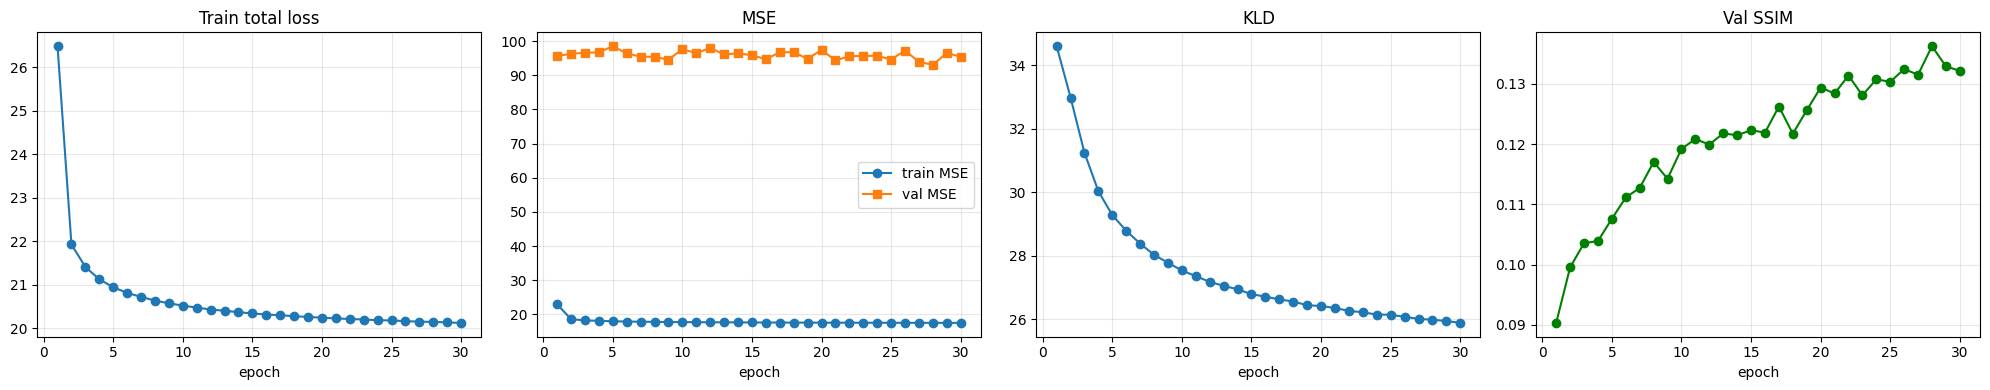

Mejor val_mse: 93.0780  |  val_ssim final: 0.1322


In [7]:
ep = range(1, len(loss_history['train_total']) + 1)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].plot(ep, loss_history['train_total'], '-o'); axes[0].set_title('Train total loss')
axes[1].plot(ep, loss_history['train_mse'], '-o', label='train MSE')
axes[1].plot(ep, loss_history['val_mse'], '-s', label='val MSE')
axes[1].set_title('MSE'); axes[1].legend()
axes[2].plot(ep, loss_history['train_kld'], '-o'); axes[2].set_title('KLD')
axes[3].plot(ep, loss_history['val_ssim'], '-o', color='green'); axes[3].set_title('Val SSIM')
for ax in axes:
    ax.set_xlabel('epoch'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/cvae_8params_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Mejor val_mse: {best_val_mse:.4f}  |  val_ssim final: {loss_history['val_ssim'][-1]:.4f}")

## 8. Visualización: generaciones del prior vs reales (test set)

Cargado checkpoint época 28  val_mse=93.0780  val_ssim=0.1363


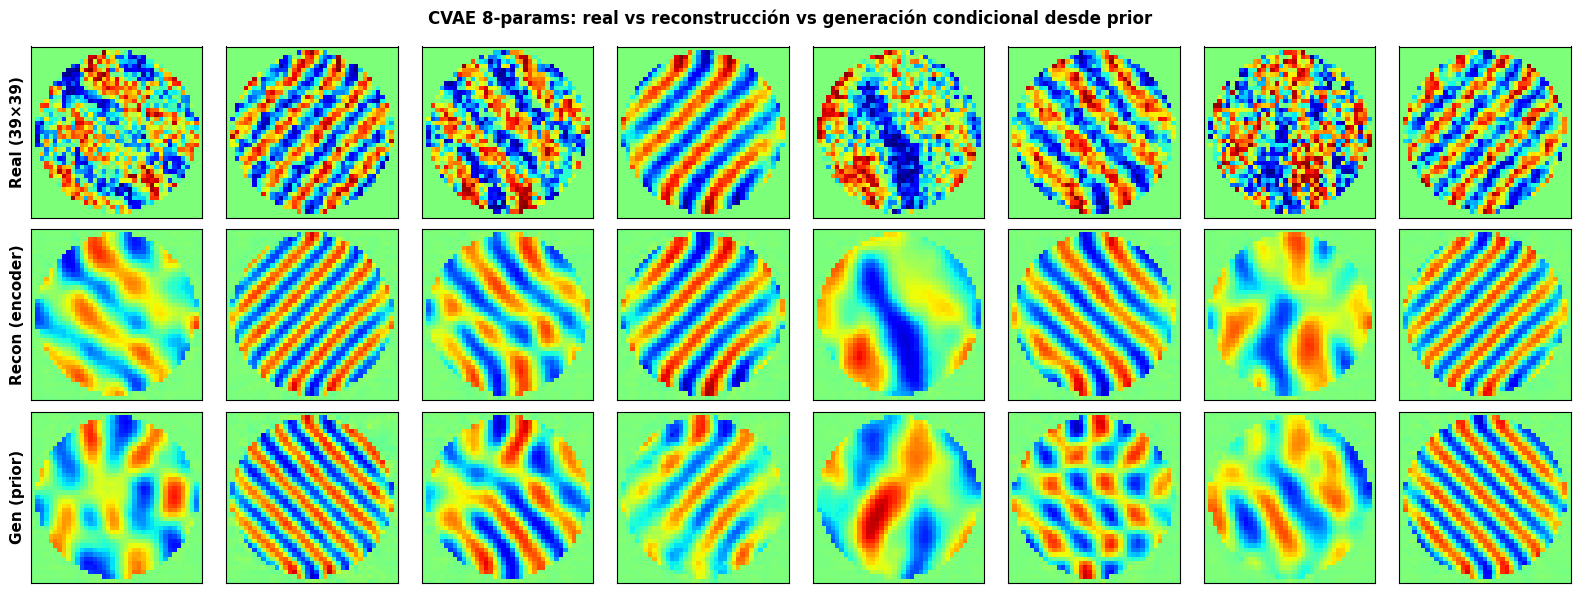

In [8]:
# Cargar mejor checkpoint
ckpt = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model'])
model.eval()
print(f"Cargado checkpoint época {ckpt['epoch']}  val_mse={ckpt['val_mse']:.4f}  val_ssim={ckpt['val_ssim']:.4f}")

# Tomar muestras del test set
with torch.no_grad():
    xt, yt = next(iter(test_loader))
    xt = xt.to(device); yt = yt.to(device)
    mu_p, logvar_p = model.get_prior(yt)
    z = model.reparameterize(mu_p, logvar_p)
    recon_prior = model.decode(z, yt)
    recon_enc, _, _, _, _ = model(xt, yt)

# Crop a 39×39 para visualización (zona física)
xt_c   = crop_to_orig(xt)
enc_c  = crop_to_orig(recon_enc)
prior_c = crop_to_orig(recon_prior)

n_show = 8
fig, axes = plt.subplots(3, n_show, figsize=(2*n_show, 6))
for i in range(n_show):
    axes[0, i].imshow(xt_c[i, 0].cpu().numpy(),    cmap='jet', vmin=0, vmax=1, interpolation='nearest')
    axes[1, i].imshow(enc_c[i, 0].cpu().numpy(),   cmap='jet', vmin=0, vmax=1, interpolation='nearest')
    axes[2, i].imshow(prior_c[i, 0].cpu().numpy(), cmap='jet', vmin=0, vmax=1, interpolation='nearest')
    for j in range(3): axes[j, i].set_xticks([]); axes[j, i].set_yticks([])
axes[0, 0].set_ylabel('Real (39×39)',           fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Recon (encoder)',         fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('Gen (prior)',             fontsize=11, fontweight='bold')
fig.suptitle('CVAE 8-params: real vs reconstrucción vs generación condicional desde prior',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/cvae_8params_samples.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Evaluación en test set completo

In [9]:
model.eval()
t_mse = 0.0; t_ssim_gen = 0.0; t_ssim_enc = 0.0; n_te = 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device); yb = yb.to(device)
        # Generativa (desde prior)
        mu_p, logvar_p = model.get_prior(yb)
        z = model.reparameterize(mu_p, logvar_p)
        gen = model.decode(z, yb)
        # Reconstrucción (desde encoder)
        recon, _, _, _, _ = model(xb, yb)

        # Crop a 39×39 (zona física) antes de calcular métricas
        xb_c   = crop_to_orig(xb)
        gen_c  = crop_to_orig(gen)
        recon_c = crop_to_orig(recon)

        t_mse += F.mse_loss(gen_c, xb_c, reduction='sum').item()
        t_ssim_gen += ssim_torch(gen_c,   xb_c, data_range=1.0, size_average=False).sum().item()
        t_ssim_enc += ssim_torch(recon_c, xb_c, data_range=1.0, size_average=False).sum().item()
        n_te += xb.size(0)

test_mse = t_mse / n_te
test_ssim_gen = t_ssim_gen / n_te
test_ssim_enc = t_ssim_enc / n_te
print(f"Test set ({n_te:,} muestras, métricas en zona física 39×39):")
print(f"  MSE (gen)             = {test_mse:.4f}")
print(f"  SSIM generación prior = {test_ssim_gen:.4f}")
print(f"  SSIM recon encoder    = {test_ssim_enc:.4f}")

metrics = {
    'test_mse': test_mse,
    'test_ssim_gen': test_ssim_gen,
    'test_ssim_enc': test_ssim_enc,
    'best_epoch': ckpt['epoch'],
    'best_val_mse': ckpt['val_mse'],
    'best_val_ssim': ckpt['val_ssim'],
}
with open('/kaggle/working/cvae_8params_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"\nMétricas guardadas en /kaggle/working/cvae_8params_metrics.json")

Test set (25,451 muestras, métricas en zona física 39×39):
  MSE (gen)             = 92.4763
  SSIM generación prior = 0.1332
  SSIM recon encoder    = 0.6686

Métricas guardadas en /kaggle/working/cvae_8params_metrics.json
